# Algoritmo de Dijkstra — Análise de Complexidade

**Execute:** `Kernel → Restart & Run All` (a **célula 1** carrega tudo).

> Pré-requisito: `npm run benchmark:all`


In [ ]:
%matplotlib inline

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

NOTEBOOKS_DIR = ROOT / "notebooks"
PLOT_UTILS_PATH = NOTEBOOKS_DIR / "plot_utils.py"
if not PLOT_UTILS_PATH.is_file():
    raise FileNotFoundError(f"plot_utils.py não encontrado: {PLOT_UTILS_PATH}")

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# Carrega plot_utils sempre do arquivo (evita cache / versão antiga)
_spec = importlib.util.spec_from_file_location("plot_utils", PLOT_UTILS_PATH)
plot_utils = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(plot_utils)
sys.modules["plot_utils"] = plot_utils

from plot_utils import *  # noqa: F403

_required = (
    "plot_heatmap_times",
    "plot_speedup_heatmap",
    "plot_tempo_vs_arestas",
    "enrich_dataframe",
    "load_results",
    "load_rounds",
)
_missing = [n for n in _required if not callable(globals().get(n))]
if _missing:
    raise ImportError(f"plot_utils incompleto, faltam: {_missing}. Arquivo: {PLOT_UTILS_PATH}")

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
GRAPHS_DIR = DATA_DIR / "graficos"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

df_raw = load_results(DATA_DIR)
df = enrich_dataframe(df_raw)
rounds_df = load_rounds(DATA_DIR)

print(f"Projeto: {ROOT}")
print(f"plot_utils: {PLOT_UTILS_PATH} ({PLOT_UTILS_PATH.stat().st_size} bytes)")
print("Colunas:", ", ".join(df.columns))
print(f"Registros: {len(df)} | Rodadas: {0 if rounds_df is None else len(rounds_df)}")
print("OK — funções da seção 7 disponíveis (plot_heatmap_times, etc.)")



In [ ]:
# Opcional: só se editou plot_utils.py — normalmente basta a célula 1
exec(open(NOTEBOOKS_DIR / 'plot_utils.py').read(), plot_utils.__dict__)
from plot_utils import *  # noqa: F403
df = enrich_dataframe(df_raw)
rounds_df = load_rounds(DATA_DIR)
print('plot_utils recarregado')


## 1. Descrição do algoritmo

### Problema resolvido
Dado um grafo **ponderado** com pesos **não negativos** e um vértice origem `s`,
calcular a **distância mínima** de `s` até todos os demais vértices (Single-Source Shortest Path).

### Lógica geral
1. Inicializa distâncias: `dist[s] = 0`, demais = ∞.
2. Mantém uma **fila de prioridade** (min-heap) com `(distância, vértice)`.
3. Extrai o vértice `u` com menor distância provisória.
4. Para cada vizinho `v` de `u`, tenta **relaxar** a aresta: se `dist[u] + w(u,v) < dist[v]`, atualiza `dist[v]` e insere `v` no heap.
5. Repete até esvaziar o heap.

### Pseudocódigo
```
DIJKSTRA(G, s):
    para cada v em V: dist[v] ← ∞
    dist[s] ← 0
    Q ← fila de prioridade com (0, s)
    enquanto Q não vazia:
        (d, u) ← extrair_mínimo(Q)
        se d > dist[u]: continuar
        para cada (v, w) em adj[u]:
            se dist[u] + w < dist[v]:
                dist[v] ← dist[u] + w
                inserir(Q, (dist[v], v))
    retornar dist
```

## 2. Classificação assintótica

Implementação com **heap binário** (Python `heapq` / heap manual em JS):

| Notação | Complexidade | Quando |
|---------|--------------|--------|
| **O** | O((V + E) log V) | Pior e caso médio (heap) |
| **Ω** | Ω(V + E) | Precisa visitar vértices e arestas |
| **Θ** | Θ((V + E) log V) | Grafo genérico com heap binário |

**Pior caso estrutural:** grafo **completo** (E ≈ V²) → comportamento próximo de **O(V² log V)**.

**Melhor caso (entrada):** grafo **estrela** na origem (E = V − 1) → próximo de **O(V log V)**.

## 3. Metodologia experimental

- **30 rodadas** por cenário (melhor / médio / pior) e por tamanho (pequeno, médio, grande).
- **Python:** `time.perf_counter()` — **JavaScript:** `performance.now()`.
- **Hardware:** _(descrever CPU, RAM, SO do computador usado nos testes)_.
- **Isolamento:** fechar programas em segundo plano durante os benchmarks.

| Cenário | Grafo gerado | Intuição |
|---------|--------------|----------|
| Melhor | Estrela na origem | Poucas arestas, poucas extrações do heap |
| Médio | Aleatório esparsificado | Comportamento típico em aplicações |
| Pior | Completo (denso) | Máximo de relaxações e operações no heap |

In [11]:
tabela = comparison_table(df)
tabela.style.set_caption("Tempo médio ± desvio-padrão (ms) — 30 rodadas")


,Caso,Tamanho,n,Arestas,Python (ms),JavaScript (ms)
0,medio,pequeno,300,1651,—,0.081 ± 0.019
1,medio,pequeno,300,1706,0.263 ± 0.060,—
2,medio,medio,1500,10933,2.028 ± 0.157,—
3,medio,medio,1500,11073,—,0.685 ± 0.216
4,medio,grande,4000,32834,7.786 ± 0.659,—
5,medio,grande,4000,33318,—,2.423 ± 0.481
6,melhor,pequeno,300,149,0.080 ± 0.006,—
7,melhor,pequeno,300,299,—,0.124 ± 0.130
8,melhor,medio,1500,749,0.449 ± 0.047,—
9,melhor,medio,1500,1499,—,0.232 ± 0.052


### Tabela completa de métricas

Além da média e do desvio, o benchmark registra mediana, percentis, coeficiente de variação, densidade do grafo e throughput.


In [ ]:
metrics_summary_table(df)


## 4.1 Dispersão das 30 rodadas (melhor caso)

Caixas mostram a distribuição de cada rodada; útil para ver outliers e estabilidade.


In [ ]:
plot_interval_range(df, "melhor")
plt.show()


## 4. Melhor caso

Grafo em forma de **estrela**: vértice 0 ligado a todos os outros, com **E = n − 1**.
O algoritmo relaxa poucas arestas após fixar a origem; o heap permanece pequeno.

Esperamos crescimento próximo de **O(n log n)** na prática.

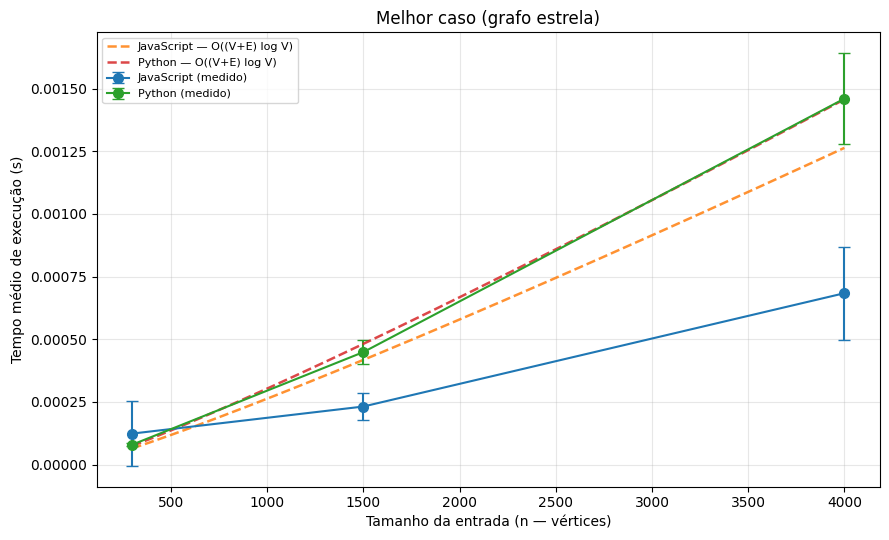

In [2]:
plot_case(df, "melhor")
plt.show()


### Interpretação — melhor caso

- Os pontos medidos devem acompanhar a curva tracejada **O((V+E) log V)**.
- **JavaScript (V8)** costuma ser mais rápido que Python interpretado em grafos pequenos/médios.
- Barras de erro (desvio-padrão) pequenas indicam medições estáveis.

## 5. Caso médio

Grafo **aleatório esparsificado** (probabilidade de aresta ∝ ln(n)/n).
Modela redes reais (rotas, conexões sociais esparsas).

Complexidade esperada: **O((V + E) log V)** com E moderado.

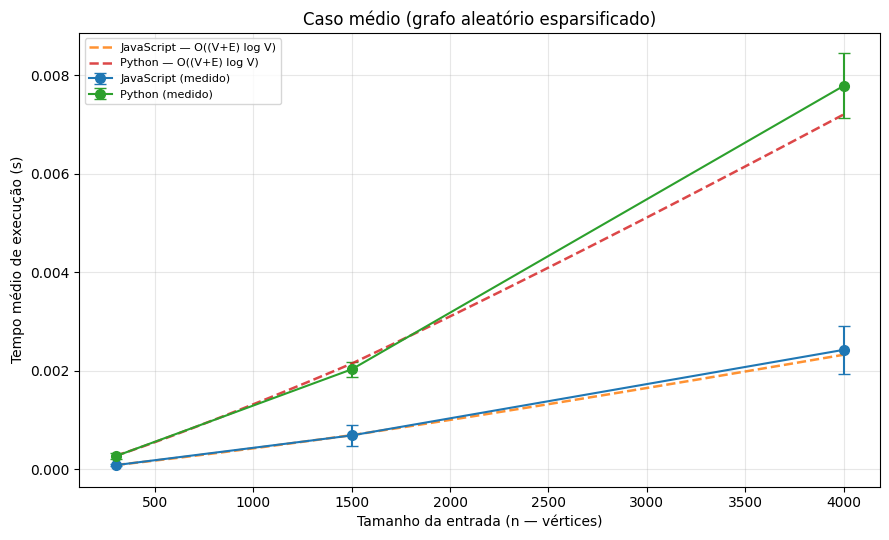

In [10]:
plot_case(df, "medio")
plt.show()


In [ ]:
plot_case(df, "medio", use_log=True)
plt.gca().set_title(CASE_LABELS["medio"] + " — escala log-log")
plt.show()


### 5.1 Faixa de dispersão (caso médio)


In [ ]:
plot_interval_range(df, "medio")
plt.show()


### Interpretação — caso médio

No gráfico **log-log**, uma reta aproximada sugere crescimento polinomial/logarítmico estável.
Compare se a inclinação dos pontos se aproxima da curva teórica ajustada.

## 6. Pior caso

Grafo **completo**: cada par de vértices tem aresta → **E ≈ n(n−1)/2**.
Força o máximo de operações no heap; é o cenário mais lento nos experimentos.

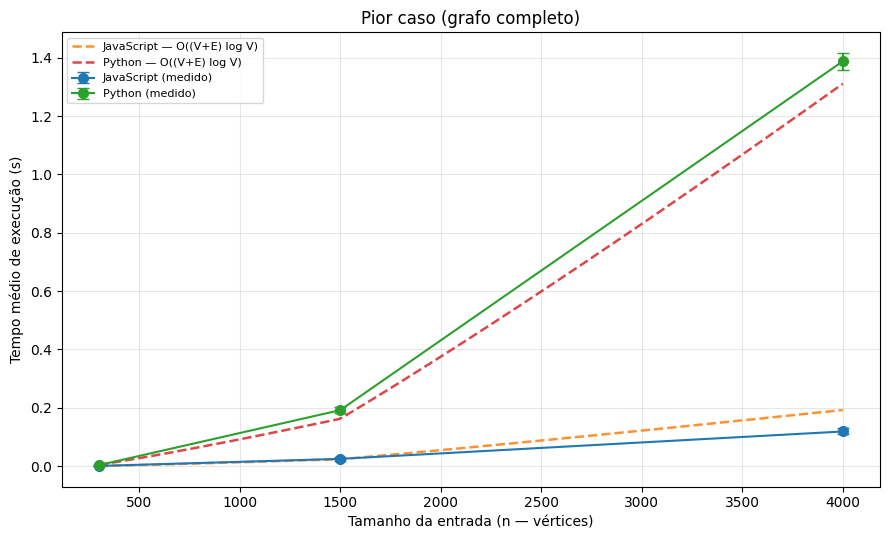

In [9]:
plot_case(df, "pior")
plt.show()


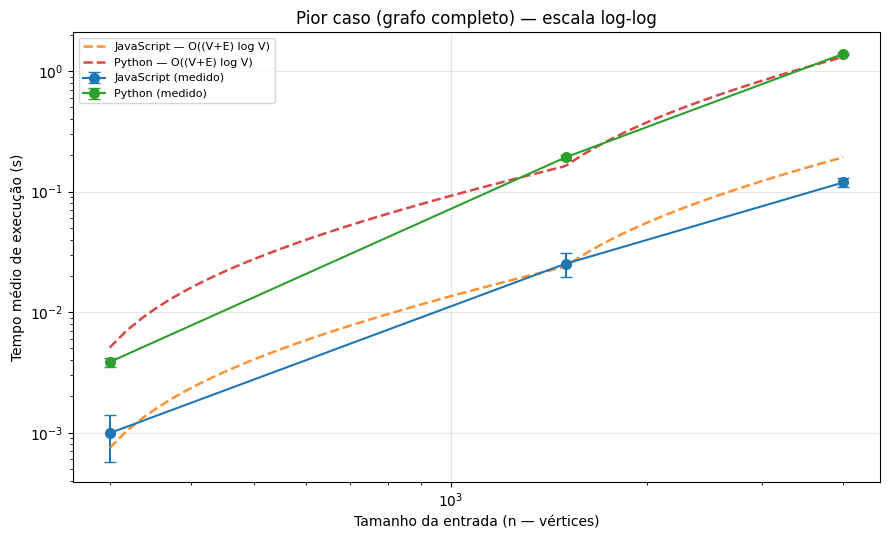

In [8]:
plot_case(df, "pior", use_log=True)
plt.gca().set_title(CASE_LABELS["pior"] + " — escala log-log")
plt.show()


### Interpretação — pior caso

- O salto de tempo entre `n=1500` e `n=4000` é forte — coerente com **E ≈ n²**.
- Python fica bem mais lento que JavaScript em grafos densos (overhead do interpretador + heap em Python).
- A curva teórica ajustada valida a aderência do modelo **O((V+E) log V)** aos dados.

## 6.1 Dispersão no pior caso


In [ ]:
plot_interval_range(df, "pior")
plt.show()


## 7. Análises avançadas

Seção expandida: heatmaps, speedup, relação tempo–arestas, densidade, throughput, aderência ao modelo e distribuição por rodada.


In [ ]:
# Recarrega plot_utils (use se aparecer ImportError na seção 7)
import importlib
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "data").exists() and (_root.parent / "data").exists():
    _root = _root.parent
_nb = str(_root / "notebooks")
if _nb not in sys.path:
    sys.path.insert(0, _nb)

import plot_utils
importlib.reload(plot_utils)
from plot_utils import *  # noqa: F403

if "df_raw" not in globals():
    raise RuntimeError("Execute primeiro a célula 1 (setup).")
df = enrich_dataframe(df_raw)
rounds_df = load_rounds(DATA_DIR)
assert callable(plot_heatmap_times), "plot_heatmap_times ausente — salve plot_utils.py e reinicie o kernel."
print("Seção 7: funções de gráfico carregadas.")


### 7.1 Heatmaps de tempo


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_heatmap_times(df, "python", ax=axes[0])
plot_heatmap_times(df, "javascript", ax=axes[1])
plt.tight_layout()
plt.show()


### 7.2 Speedup JavaScript / Python


In [ ]:
plot_speedup_heatmap(df)
plt.show()


### 7.3 Tempo vs número de arestas (escala log-log)


In [ ]:
plot_tempo_vs_arestas(df)
plt.show()


### 7.4 Tempo vs densidade do grafo


In [ ]:
plot_tempo_vs_densidade(df)
plt.show()


### 7.5 Throughput (arestas processadas por segundo)


In [ ]:
plot_throughput(df)
plt.show()


### 7.6 Estabilidade — coeficiente de variação


In [ ]:
plot_coeficiente_variacao(df)
plt.show()


### 7.7 Comparação direta (barras, escala log)


In [ ]:
plot_comparison_bars(df)
plt.show()


### 7.8 Aderência ao modelo O((V+E) log V)


In [ ]:
plot_residual_model(df)
plt.show()


### 7.9 Distribuição das rodadas individuais


In [ ]:
plot_rounds_distribution(rounds_df)
plt.show()


### 7.10 Painel resumo


In [ ]:
plot_dashboard(df)
plt.show()


### 7.12 Matriz de correlação entre métricas


In [ ]:
plot_correlacao(df)
plt.show()


### 7.13 Mediana vs média (detecção de outliers)


In [ ]:
plot_mediana_vs_media(df)
plt.show()


### 7.14 Fator de crescimento entre tamanhos


In [ ]:
plot_fator_crescimento(df)
plt.show()


### 7.15 Tempo normalizado por aresta (μs/aresta)


In [ ]:
plot_tempo_por_aresta(df)
plt.show()


### 7.16 Perfil de percentis (min, P25, mediana, P75, P95, max)


In [ ]:
for caso in ('melhor', 'medio', 'pior'):
    plot_percentis_caso(df, caso)
    plt.suptitle(CASE_LABELS[caso])
    plt.show()


### 7.17 Estrutura E vs n dos grafos de teste


In [ ]:
plot_arestas_vs_n(df)
plt.show()


### 7.18 Razão tempo medido / modelo teórico


In [ ]:
plot_razao_empirico_teorico(df)
plt.show()


### 7.19 Estatísticas descritivas (todas as colunas numéricas)


In [ ]:
from IPython.display import display
display(describe_numeric(df))


### 7.20 Melhor caso — escala log-log


In [ ]:
plot_case(df, "melhor", use_log=True)
plt.gca().set_title(CASE_LABELS["melhor"] + " — escala log-log")
plt.show()


### 7.21 Resumo em DataFrame: speedup e diferença percentual


In [ ]:
py = df[df["linguagem"]=="python"][["caso","tamanho","n","media_s"]].rename(columns={"media_s":"py_s"})
js = df[df["linguagem"]=="javascript"][["caso","tamanho","n","media_s"]].rename(columns={"media_s":"js_s"})
cmp = py.merge(js, on=["caso","tamanho"], how="outer", suffixes=("_py","_js"))
cmp["speedup_py_js"] = cmp["py_s"] / cmp["js_s"]
cmp["diff_pct"] = (cmp["py_s"] - cmp["js_s"]) / cmp[["py_s","js_s"]].min(axis=1) * 100
cmp[["caso","tamanho","n_py","n_js","py_s","js_s","speedup_py_js","diff_pct"]].style.format({
    "py_s": "{:.6f}", "js_s": "{:.6f}", "speedup_py_js": "{:.2f}", "diff_pct": "{:+.1f}%"
}).set_caption("Comparação por caso/tamanho (n pode diferir entre linguagens)")


### 7.22 Exportar PNGs e CSVs

Gera automaticamente todos os arquivos em `data/graficos/`:


In [ ]:
paths = export_all_figures(df, DATA_DIR / 'graficos', rounds_df)
print(f'{len(paths)} gráficos + CSVs em {DATA_DIR / "graficos"}')
for p in paths:
    print(' -', p.name)


## 8. Aplicabilidade e limitações

**Eficiente quando:**
- Pesos são não negativos.
- O grafo é esparso (E ≪ V²) — GPS, redes de computadores, rotas.

**Limitações:**
- **Não funciona** com arestas de peso negativo (use Bellman-Ford).
- Em grafos muito densos, custo alto; estruturas Fibonacci heap melhoram teoricamente para O(E + V log V).
- Memória: lista de adjacência + heap para grafos enormes.

## 9. Reflexão: classe P, NP e problemas relacionados

**Dijkstra pertence à classe P?**  
**Sim.** Para grafos com pesos não negativos representados de forma razoável,
o problema de caminho mínimo com uma origem é resolvível em tempo polinomial
(ex.: O((V+E) log V) com heap binário).

**Existe versão NP?**  
A versão de **decisão** associada a otimização de caminho pode ser colocada em NP
em problemas mais gerais (ex.: caminho mínimo com restrições extras), mas o
**SSSP padrão com pesos não negativos não é NP-completo** — está em P.

**Problemas semelhantes NP-completos:**
- **TSP (Caixeiro Viajante):** visitar todas as cidades uma vez — otimização, NP-difícil.
- **Caminho hamiltoniano:** existe ciclo/caminho que visita cada vértice uma vez?
- **Caminho mínimo com k caminhos disjuntos** (variantes restritas) podem escalar para problemas NP-difíceis.

Dijkstra resolve eficientemente o subproblema **local-guloso com pesos ≥ 0**;
não deve ser confundido com TSP ou com grafos que permitem pesos negativos.

## 10. Conclusões

1. Os experimentos confirmam a tendência teórica **O((V+E) log V)** (resíduos e razão empírico/teórico).
2. O **pior caso (grafo completo)** domina o tempo; o **melhor caso (estrela)** é ordens de magnitude menor.
3. **Throughput**, **μs/aresta**, **CV** e **percentis** complementam a média — ver seções 7.5–7.19.
4. Heatmaps, speedup e correlação consolidam diferenças **Python vs JavaScript** (quando `n` coincide).
5. Arquivos exportados: `data/graficos/*.png`, `tabela_metricas_completa.csv`, `estatisticas_descritivas.csv`.

---